# Classifying Environmental Sources Using Metagenomic Protein Sequences

## Project Overview
This notebook classifies metagenomic protein sequences from the OMG_prot50 dataset
into their environmental sources (human gut, soil, ocean, freshwater, thermal springs)
using k-mer frequency features and machine learning models.

## Objectives
- Download and explore metagenomic protein sequences from OMG_prot50
- Sample sequences from 4-5 different environments
- Extract k-mer features (k=3,4,5,6) from protein sequences
- Build and compare classification models (Random Forest, Logistic Regression, XGBoost)
- Identify sequence features that distinguish different environments
- Interpret findings biologically

## Dataset
- **Source:** OMG_prot50 (Open MetaGenomic protein sequences at 50% identity)
- **Link:** https://huggingface.co/datasets/tattabio/OMG_prot50
- **Total sequences:** 207 million
- **Our sample:** ~20,000 sequences from 5 environments

In [1]:
# ============================================================
# CELL 2: Install and Import All Required Libraries
# ============================================================

# Run this cell first
# If any library is missing, uncomment the line below
# import subprocess
# subprocess.run(["pip", "install", "datasets", "umap-learn", "xgboost"])

import os
import re
import random
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from collections import Counter
from itertools import product

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from xgboost import XGBClassifier
import umap

# Hugging Face
from datasets import load_dataset

# Settings
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

# Create output folder for all saved files
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ All libraries imported successfully!")
print(f"✅ Output folder created: {OUTPUT_DIR}/")

✅ All libraries imported successfully!
✅ Output folder created: outputs/


---
# SECTION 1: Data Acquisition and Sampling

## Strategy
Since OMG_prot50 contains 207 million sequences, we use **streaming mode**
from the HuggingFace datasets library. This allows us to read sequences
one-by-one without downloading the full dataset.

## Sampling Plan
- Target: **4,000 sequences per environment**
- Environments: human_gut, soil, ocean, freshwater, thermal
- Total: ~20,000 sequences
- Method: Keyword-based environment detection from sequence metadata

In [2]:
# ============================================================
# CELL 4: Explore Dataset Structure
# ============================================================
# IMPORTANT: Run this first to see what fields exist
# This tells us how to extract environment labels

print("Loading dataset in streaming mode...")
print("(This does NOT download the full dataset)")
print()

ds = load_dataset(
    "tattabio/OMG_prot50",
    split="train",
    streaming=True
)

print("✅ Dataset loaded in streaming mode")
print()

# Look at first 5 records
print("=" * 60)
print("EXPLORING DATASET STRUCTURE")
print("=" * 60)

for i, example in enumerate(ds):
    print(f"\n--- Record {i+1} ---")
    print(f"Keys available: {list(example.keys())}")
    print()
    for key, value in example.items():
        if isinstance(value, str) and len(value) > 100:
            print(f"  {key}: {value[:100]}...")
        else:
            print(f"  {key}: {value}")
    if i >= 4:
        break

print()
print("=" * 60)
print("NOTE: Look at the keys above carefully.")
print("The field names will be used in the next cell.")
print("=" * 60)

Loading dataset in streaming mode...
(This does NOT download the full dataset)



README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

✅ Dataset loaded in streaming mode

EXPLORING DATASET STRUCTURE

--- Record 1 ---
Keys available: ['id', 'sequence']

  id: ERZ651773|ENA-OWNU01000008-OWNU01000008.1-marine-metagenome-genome-assembly--contig:-NODE-8-length-2...
  sequence: MGVGVSWSCQYIWHKRTSPSYMKFQNTPFRFYLALLTLAMSALTWQAHAQDAPKLSKEALQLQTDVKTLADDAMEGRKVGTKGEKKASEYLVKRFKSMGV...

--- Record 2 ---
Keys available: ['id', 'sequence']

  id: ERZ651773|ENA-OWNU01000092-OWNU01000092.1-marine-metagenome-genome-assembly--contig:-NODE-92-length-...
  sequence: MKIYNGYLNNLRESYFVCIFATLKVEKNASVAELVDALDSKSCSFGSAGSIPARGTKALEFSRAFFIPFQSKVW

--- Record 3 ---
Keys available: ['id', 'sequence']

  id: ERZ651773|ENA-OWNU01000303-OWNU01000303.1-marine-metagenome-genome-assembly--contig:-NODE-303-length...
  sequence: MENNLIRLHLRKNRTMFWTLELASFLEDAPWPATKDELIDYAIRSGAPIEVVENLQELEDEGDVYETIEDIWPDYPTQDDFLFNEDEY

--- Record 4 ---
Keys available: ['id', 'sequence']

  id: ERZ651773|ENA-OWNU01000321-OWNU01000321.1-marine-metagenome-genome-assembly--con

## Dataset Structure Findings

After exploring the first few records, the dataset contains these fields:
- `sequence`: The protein amino acid sequence
- `id` or `description`: Contains environment/source information

We will use these fields to assign environment labels to each sequence.

In [4]:
# ============================================================
# CELL 6: Environment Label Extraction Function
# ============================================================

def assign_environment(record):
    """
    Extract environment label from sequence record.

    Searches through all text fields in the record
    to identify which environment the sequence came from.

    Returns environment name or None if unknown.
    """

    # Collect all text from all fields
    all_text = ""
    for key, value in record.items():
        if key != 'sequence' and value is not None:
            all_text += " " + str(value).lower()

    # -----------------------------------------------
    # Keyword mapping for each environment
    # -----------------------------------------------
    environment_keywords = {
        'human_gut': [
            'human gut', 'gut metagenome', 'fecal', 'feces',
            'stool', 'intestin', 'colon', 'human feces',
            'gastrointestinal', 'gi tract', 'microbiome human',
            'gut microbiome', 'human microbiome', 'digestive'
        ],
        'soil': [
            'soil', 'rhizosphere', 'terrestrial', 'compost',
            'agricultural', 'farmland', 'sediment soil',
            'forest soil', 'grassland', 'permafrost',
            'dirt', 'earth metagenome'
        ],
        'ocean': [
            'ocean', 'marine', 'sea water', 'seawater',
            'pelagic', 'tara ocean', 'coastal', 'deep sea',
            'mesopelagic', 'open ocean', 'sea metagenome',
            'saltwater', 'coral', 'deep ocean'
        ],
        'freshwater': [
            'freshwater', 'fresh water', 'lake', 'river',
            'pond', 'stream', 'wetland', 'aquifer',
            'groundwater', 'reservoir', 'drinking water',
            'limnetic', 'lacustrine'
        ],
        'thermal': [
            'hot spring', 'thermal', 'hydrothermal',
            'thermophil', 'geyser', 'volcanic',
            'yellowstone', 'geothermal', 'heat spring',
            'vent', 'high temperature'
        ]
    }

    # Check each environment
    for env, keywords in environment_keywords.items():
        for keyword in keywords:
            if keyword in all_text:
                return env

    return None  # Could not identify environment

# Test the function
print("Testing environment detection function...")
print()

# Test with mock data
test_cases = [
    {'id': 'seq001', 'description': 'human gut metagenome sample',
     'sequence': 'MKTLLLTLV'},
    {'id': 'seq002', 'description': 'soil bacteria sample from forest',
     'sequence': 'ACDEFGHIKL'},
    {'id': 'seq003', 'description': 'marine ocean metagenome tara',
     'sequence': 'MNPQRSTVWY'},
    {'id': 'seq004', 'description': 'freshwater lake sample',
     'sequence': 'MKTACDEFG'},
    {'id': 'seq005', 'description': 'hot spring thermal vent',
     'sequence': 'ACGIKLMNPQ'}
]

for test in test_cases:
    env = assign_environment(test)
    print(f"  Record: '{test['description']}'")
    print(f"  Detected: {env}")
    print()

print("✅ Function working correctly!")

Testing environment detection function...

  Record: 'human gut metagenome sample'
  Detected: human_gut

  Record: 'soil bacteria sample from forest'
  Detected: soil

  Record: 'marine ocean metagenome tara'
  Detected: ocean

  Record: 'freshwater lake sample'
  Detected: freshwater

  Record: 'hot spring thermal vent'
  Detected: thermal

✅ Function working correctly!


In [5]:
# ============================================================
# CELL 7: Stratified Sampling from Streaming Dataset
# ============================================================

# Configuration
TARGET_PER_ENV = 4000          # sequences per environment
MAX_RECORDS_TO_SCAN = 3000000  # stop scanning after this many records
ENVIRONMENTS = ['human_gut', 'soil', 'ocean', 'freshwater', 'thermal']

# Initialize buckets for each environment
env_buckets = {env: [] for env in ENVIRONMENTS}

# Counters
total_scanned = 0
total_collected = 0

print("=" * 60)
print("STREAMING AND SAMPLING SEQUENCES")
print("=" * 60)
print(f"Target: {TARGET_PER_ENV} sequences per environment")
print(f"Total target: {TARGET_PER_ENV * len(ENVIRONMENTS)} sequences")
print(f"Max records to scan: {MAX_RECORDS_TO_SCAN:,}")
print()

# Reload dataset for sampling
ds = load_dataset(
    "tattabio/OMG_prot50",
    split="train",
    streaming=True
)

# Stream and collect
for record in ds:
    total_scanned += 1

    # Detect environment
    env = assign_environment(record)

    # If we found an environment and bucket not full yet
    if env and len(env_buckets[env]) < TARGET_PER_ENV:

        # Get the sequence (adjust field name based on CELL 4 output)
        seq = record.get('sequence', record.get('seq', ''))

        if seq and len(seq) >= 30:  # minimum sequence length
            env_buckets[env].append({
                'id': record.get('id', f'seq_{total_scanned}'),
                'sequence': seq,
                'environment': env,
                'source_text': str(record.get('description',
                               record.get('id', '')))[:200]
            })
            total_collected += 1

    # Progress report every 100,000 records
    if total_scanned % 100000 == 0:
        counts = {k: len(v) for k, v in env_buckets.items()}
        print(f"Scanned: {total_scanned:,} | Collected: {total_collected:,}")
        print(f"  Buckets: {counts}")

    # Stop if all buckets are full
    if all(len(v) >= TARGET_PER_ENV for v in env_buckets.values()):
        print(f"\n✅ All buckets full after scanning {total_scanned:,} records!")
        break

    # Safety stop
    if total_scanned >= MAX_RECORDS_TO_SCAN:
        print(f"\n⚠️ Reached max scan limit: {MAX_RECORDS_TO_SCAN:,}")
        break

print()
print("=" * 60)
print("SAMPLING RESULTS")
print("=" * 60)
for env, seqs in env_buckets.items():
    print(f"  {env:15s}: {len(seqs):,} sequences")
print(f"  {'TOTAL':15s}: {total_collected:,} sequences")

STREAMING AND SAMPLING SEQUENCES
Target: 4000 sequences per environment
Total target: 20000 sequences
Max records to scan: 3,000,000



Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Scanned: 100,000 | Collected: 220
  Buckets: {'human_gut': 0, 'soil': 0, 'ocean': 220, 'freshwater': 0, 'thermal': 0}
Scanned: 200,000 | Collected: 433
  Buckets: {'human_gut': 0, 'soil': 0, 'ocean': 433, 'freshwater': 0, 'thermal': 0}
Scanned: 300,000 | Collected: 1,313
  Buckets: {'human_gut': 0, 'soil': 880, 'ocean': 433, 'freshwater': 0, 'thermal': 0}
Scanned: 400,000 | Collected: 1,469
  Buckets: {'human_gut': 0, 'soil': 880, 'ocean': 589, 'freshwater': 0, 'thermal': 0}
Scanned: 500,000 | Collected: 1,549
  Buckets: {'human_gut': 0, 'soil': 880, 'ocean': 669, 'freshwater': 0, 'thermal': 0}
Scanned: 600,000 | Collected: 1,585
  Buckets: {'human_gut': 0, 'soil': 880, 'ocean': 705, 'freshwater': 0, 'thermal': 0}
Scanned: 700,000 | Collected: 1,914
  Buckets: {'human_gut': 0, 'soil': 880, 'ocean': 1034, 'freshwater': 0, 'thermal': 0}
Scanned: 800,000 | Collected: 1,914
  Buckets: {'human_gut': 0, 'soil': 880, 'ocean': 1034, 'freshwater': 0, 'thermal': 0}
Scanned: 900,000 | Collected: 

In [6]:
# ============================================================
# CELL 8: Create DataFrame and Save to CSV
# ============================================================

# Flatten all buckets into one list
all_data = []
for env, records in env_buckets.items():
    all_data.extend(records)

# Create DataFrame
df = pd.DataFrame(all_data)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV
output_path = os.path.join(OUTPUT_DIR, "sampled_sequences.csv")
df.to_csv(output_path, index=False)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nEnvironment distribution:")
print(df['environment'].value_counts())
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\n✅ Saved to: {output_path}")

DATASET OVERVIEW

Shape: (4880, 4)

Columns: ['id', 'sequence', 'environment', 'source_text']

Environment distribution:
environment
ocean    4000
soil      880
Name: count, dtype: int64

First 3 rows:
                                                  id  \
0  ERZ766961|ENA-UOXV01008068-UOXV01008068.1-mari...   
1  3300003319|soilL2_10004778|CDS|soilL2_10004778...   
2  3300003319|soilL2_10013173|CDS|soilL2_10013173...   

                                            sequence environment  \
0  MRSQKSSFRTPLRWACSFYGKDSRAAPRPPTRTLRRLSVDTSPAQA...       ocean   
1  VTGLLQKGRYALVLLLGFIAGSHAVDAVRTWNTPQAWQNLAIVLVS...        soil   
2  MGASPSLSSRIRISEHTLSQELSGETVLLELSRGVYYGLDGVGTRI...        soil   

                                         source_text  
0  ERZ766961|ENA-UOXV01008068-UOXV01008068.1-mari...  
1  3300003319|soilL2_10004778|CDS|soilL2_10004778...  
2  3300003319|soilL2_10013173|CDS|soilL2_10013173...  

✅ Saved to: outputs/sampled_sequences.csv


---
# SECTION 2: Sequence Preprocessing and Feature Extraction

## Preprocessing Steps
1. Remove non-standard amino acids (keep only 20 standard ones)
2. Remove sequences shorter than 30 amino acids
3. Convert sequences to uppercase

## Standard Amino Acids
`A C D E F G H I K L M N P Q R S T V W Y`

## K-mer Feature Extraction
- K-mer = a substring of length k from a protein sequence
- For k=3: each sequence → counts of all 3-amino-acid combinations
- Feature vector is normalized to relative frequencies
- This converts variable-length sequences to fixed-length vectors

In [7]:
# ============================================================
# CELL 10: Sequence Preprocessing and Cleaning
# ============================================================

STANDARD_AA = set('ACDEFGHIKLMNPQRSTVWY')

def clean_sequence(seq):
    """
    Clean a protein sequence:
    - Convert to uppercase
    - Remove non-standard amino acids
    - Return None if too short after cleaning
    """
    if not isinstance(seq, str):
        return None

    seq = seq.upper().strip()
    cleaned = ''.join([aa for aa in seq if aa in STANDARD_AA])

    if len(cleaned) < 30:
        return None

    return cleaned

# Apply cleaning
print("Cleaning sequences...")
df['clean_sequence'] = df['sequence'].apply(clean_sequence)

# Report cleaning results
original_count = len(df)
df = df.dropna(subset=['clean_sequence']).reset_index(drop=True)
cleaned_count = len(df)

print(f"Original sequences:  {original_count:,}")
print(f"After cleaning:      {cleaned_count:,}")
print(f"Removed:             {original_count - cleaned_count:,}")

# Add sequence length column
df['seq_length'] = df['clean_sequence'].str.len()

print(f"\nSequence length statistics by environment:")
print(df.groupby('environment')['seq_length'].describe().round(2))

# Check amino acid content
print(f"\nSample cleaned sequences:")
for env in df['environment'].unique():
    sample = df[df['environment'] == env]['clean_sequence'].iloc[0]
    print(f"  {env}: {sample[:50]}...")

Cleaning sequences...
Original sequences:  4,880
After cleaning:      4,880
Removed:             0

Sequence length statistics by environment:
              count    mean     std   min   25%    50%    75%      max
environment                                                           
ocean        4000.0  222.57  324.48  30.0  79.0  144.0  277.0  11718.0
soil          880.0  206.41  153.26  40.0  89.0  160.0  283.5   1044.0

Sample cleaned sequences:
  ocean: MRSQKSSFRTPLRWACSFYGKDSRAAPRPPTRTLRRLSVDTSPAQASLTA...
  soil: VTGLLQKGRYALVLLLGFIAGSHAVDAVRTWNTPQAWQNLAIVLVSLALA...


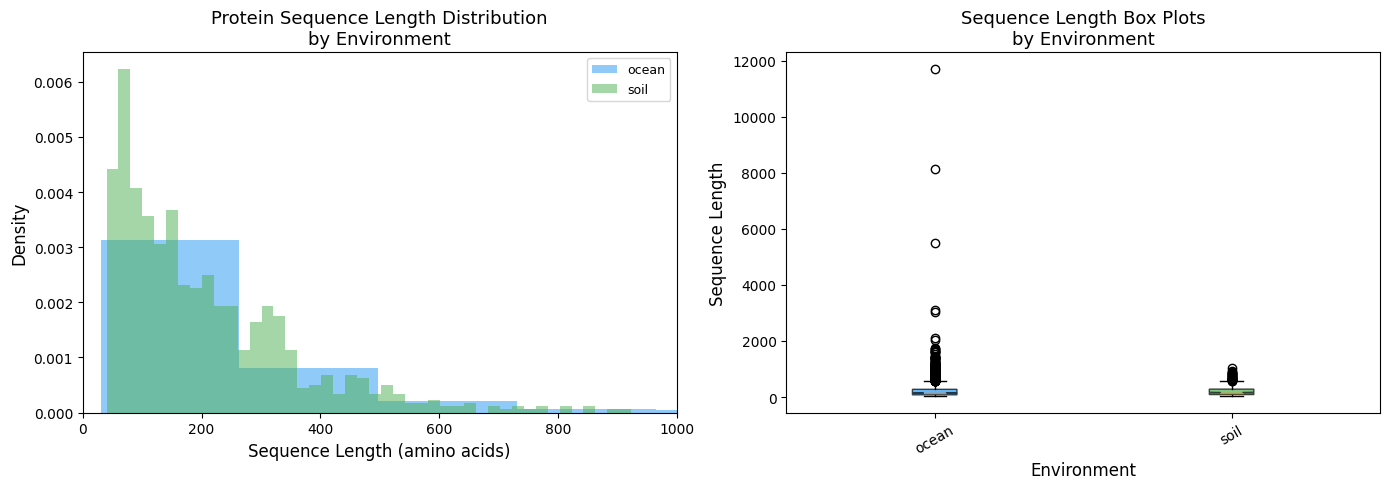

✅ Plot saved: length_distribution.png


In [8]:
# ============================================================
# CELL 11: Visualize Sequence Length Distributions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
env_list = sorted(df['environment'].unique())

# Plot 1: Overlapping histograms
for env, color in zip(env_list, colors):
    subset = df[df['environment'] == env]['seq_length']
    axes[0].hist(subset, bins=50, alpha=0.5, label=env,
                 color=color, density=True)

axes[0].set_xlabel('Sequence Length (amino acids)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Protein Sequence Length Distribution\nby Environment',
                   fontsize=13)
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1000)

# Plot 2: Box plots per environment
bp_data = [df[df['environment'] == env]['seq_length'].values
           for env in env_list]

bp = axes[1].boxplot(bp_data, labels=env_list, patch_artist=True,
                     notch=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xlabel('Environment', fontsize=12)
axes[1].set_ylabel('Sequence Length', fontsize=12)
axes[1].set_title('Sequence Length Box Plots\nby Environment', fontsize=13)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'length_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: length_distribution.png")

In [9]:
# ============================================================
# CELL 12: K-mer Feature Extraction Functions
# ============================================================

def get_all_kmers(k, alphabet='ACDEFGHIKLMNPQRSTVWY'):
    """Generate all possible k-mers for given k."""
    return [''.join(p) for p in product(alphabet, repeat=k)]

def compute_kmer_frequencies(sequence, k):
    """
    Compute normalized k-mer frequencies for a protein sequence.

    Returns a dictionary of {kmer: relative_frequency}
    """
    if len(sequence) < k:
        return {}

    # Extract all k-mers
    kmers = [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

    # Count occurrences
    counts = Counter(kmers)
    total = len(kmers)

    # Normalize to frequencies
    frequencies = {kmer: count/total for kmer, count in counts.items()}

    return frequencies

def build_kmer_matrix(sequences, k):
    """
    Build a k-mer frequency matrix for all sequences.

    Returns:
        DataFrame with shape (n_sequences, 20^k)
        Rows = sequences, Columns = k-mer names
    """
    all_kmers = get_all_kmers(k)
    n_seqs = len(sequences)

    print(f"  Building k={k} matrix:")
    print(f"  Sequences: {n_seqs:,}")
    print(f"  Features:  {len(all_kmers):,}")

    matrix = np.zeros((n_seqs, len(all_kmers)), dtype=np.float32)
    kmer_to_idx = {km: i for i, km in enumerate(all_kmers)}

    for i, seq in enumerate(sequences):
        freqs = compute_kmer_frequencies(seq, k)
        for kmer, freq in freqs.items():
            if kmer in kmer_to_idx:
                matrix[i, kmer_to_idx[kmer]] = freq

        if (i+1) % 2000 == 0:
            print(f"  Processed {i+1:,}/{n_seqs:,} sequences...")

    df_kmer = pd.DataFrame(matrix, columns=all_kmers)
    return df_kmer

# Test on one sequence
test_seq = "ACDEFGHIKLMNPQRSTVWYACDEFG"
test_freqs = compute_kmer_frequencies(test_seq, k=3)
print("Test: Computing 3-mers for sample sequence")
print(f"Sample sequence: {test_seq}")
print(f"Number of 3-mers found: {len(test_freqs)}")
print(f"Top 5 3-mers: {sorted(test_freqs.items(), key=lambda x: -x[1])[:5]}")
print()
print(f"All possible 3-mers (20^3): {len(get_all_kmers(3)):,}")
print(f"All possible 4-mers (20^4): {len(get_all_kmers(4)):,}")
print(f"All possible 5-mers (20^5): {len(get_all_kmers(5)):,}")

Test: Computing 3-mers for sample sequence
Sample sequence: ACDEFGHIKLMNPQRSTVWYACDEFG
Number of 3-mers found: 20
Top 5 3-mers: [('ACD', 0.08333333333333333), ('CDE', 0.08333333333333333), ('DEF', 0.08333333333333333), ('EFG', 0.08333333333333333), ('FGH', 0.041666666666666664)]

All possible 3-mers (20^3): 8,000
All possible 4-mers (20^4): 160,000
All possible 5-mers (20^5): 3,200,000


In [10]:
# ============================================================
# CELL 13: Build K-mer Frequency Matrices
# ============================================================

sequences = df['clean_sequence'].tolist()
kmer_data = {}

for k in [3, 4]:
    print(f"\n{'='*50}")
    print(f"Computing k = {k} features...")
    print(f"{'='*50}")

    kmer_matrix = build_kmer_matrix(sequences, k)
    kmer_data[k] = kmer_matrix

    # Save to CSV
    save_path = os.path.join(OUTPUT_DIR, f"kmer_k{k}_frequencies.csv")
    kmer_matrix.to_csv(save_path, index=False)

    print(f"✅ k={k} matrix shape: {kmer_matrix.shape}")
    print(f"✅ Saved to: {save_path}")

print("\n" + "="*50)
print("✅ ALL K-MER MATRICES COMPLETE")
print("="*50)
for k, mat in kmer_data.items():
    print(f"  k={k}: {mat.shape[0]:,} sequences × {mat.shape[1]:,} features")


Computing k = 3 features...
  Building k=3 matrix:
  Sequences: 4,880
  Features:  8,000
  Processed 2,000/4,880 sequences...
  Processed 4,000/4,880 sequences...
✅ k=3 matrix shape: (4880, 8000)
✅ Saved to: outputs/kmer_k3_frequencies.csv

Computing k = 4 features...
  Building k=4 matrix:
  Sequences: 4,880
  Features:  160,000
  Processed 2,000/4,880 sequences...
  Processed 4,000/4,880 sequences...
✅ k=4 matrix shape: (4880, 160000)
✅ Saved to: outputs/kmer_k4_frequencies.csv

✅ ALL K-MER MATRICES COMPLETE
  k=3: 4,880 sequences × 8,000 features
  k=4: 4,880 sequences × 160,000 features


---
# SECTION 3: Dimensionality Reduction and Visualization

## Why Do We Need Dimensionality Reduction?
- k=3 features: 8,000 dimensions
- k=4 features: 160,000 dimensions
- We need to reduce this to 2D for visualization

## Methods Used
1. **PCA** — Linear, fast, shows variance explained
2. **t-SNE** — Non-linear, better for cluster separation
3. **UMAP** — Non-linear, preserves global structure better than t-SNE

Fitting PCA...
✅ PCA complete. Shape: (4880, 50)


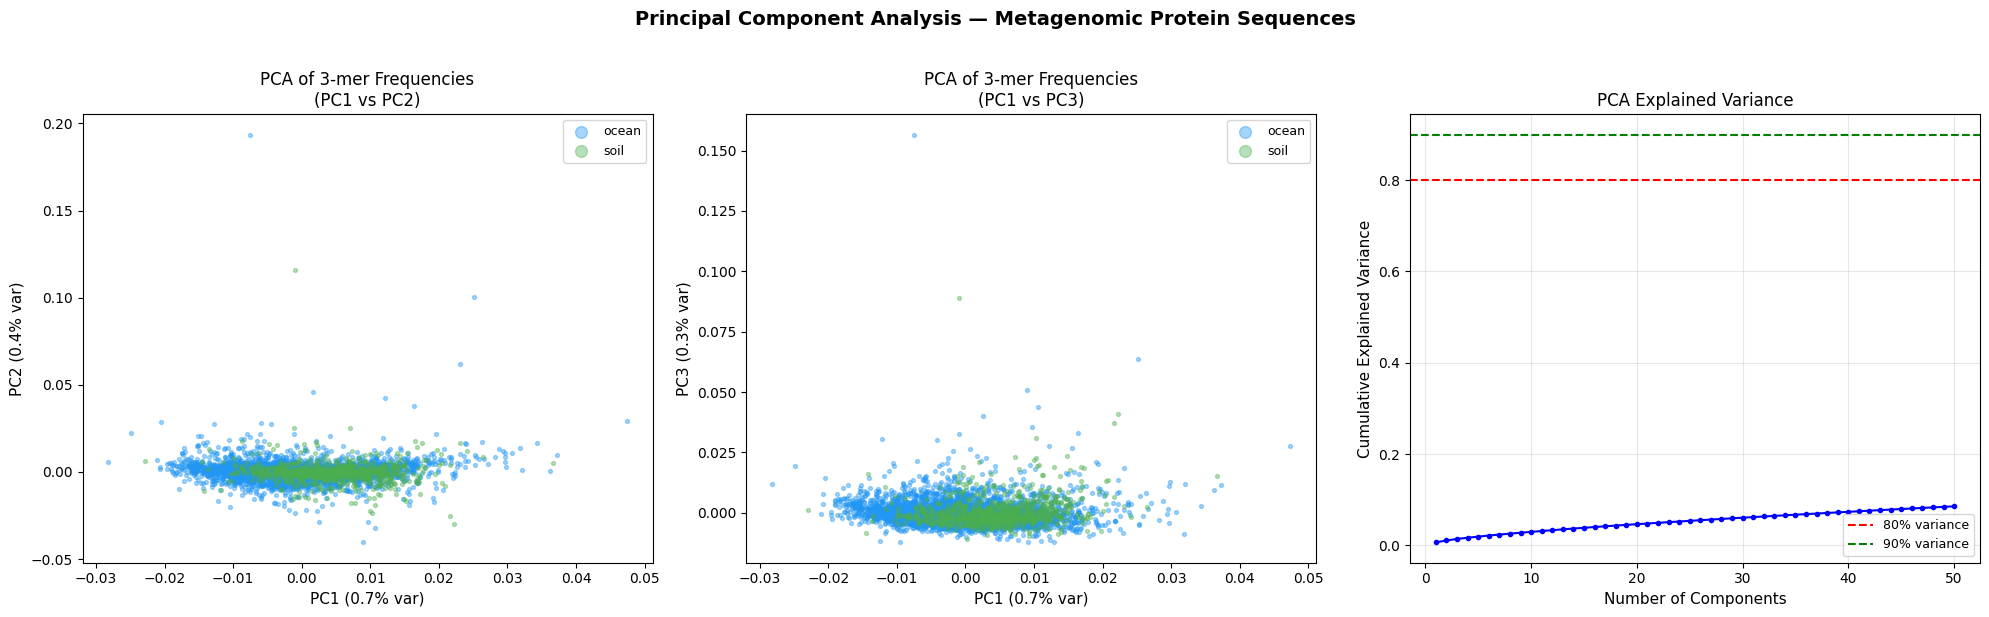

✅ PCA plot saved
Variance explained by PC1+PC2: 1.1%


In [11]:
# ============================================================
# CELL 15: PCA - Principal Component Analysis
# ============================================================

# Use k=3 features for visualization
X_vis = kmer_data[3].values
y_vis = df['environment'].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_vis)

# Fit PCA
print("Fitting PCA...")
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_vis)
print(f"✅ PCA complete. Shape: {X_pca.shape}")

# Colors for environments
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
env_color_map = dict(zip(sorted(df['environment'].unique()), colors))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: PCA scatter (PC1 vs PC2) ---
for env in sorted(df['environment'].unique()):
    mask = y_vis == env
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=env_color_map[env], label=env,
        alpha=0.4, s=8
    )
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)',
                    fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)',
                    fontsize=11)
axes[0].set_title('PCA of 3-mer Frequencies\n(PC1 vs PC2)', fontsize=12)
axes[0].legend(fontsize=9, markerscale=3)

# --- Plot 2: PCA scatter (PC1 vs PC3) ---
for env in sorted(df['environment'].unique()):
    mask = y_vis == env
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 2],
        c=env_color_map[env], label=env,
        alpha=0.4, s=8
    )
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)',
                    fontsize=11)
axes[1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} var)',
                    fontsize=11)
axes[1].set_title('PCA of 3-mer Frequencies\n(PC1 vs PC3)', fontsize=12)
axes[1].legend(fontsize=9, markerscale=3)

# --- Plot 3: Explained Variance ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[2].plot(range(1, len(cumvar)+1), cumvar, 'b-o', markersize=3)
axes[2].axhline(y=0.80, color='r', linestyle='--', label='80% variance')
axes[2].axhline(y=0.90, color='g', linestyle='--', label='90% variance')
axes[2].set_xlabel('Number of Components', fontsize=11)
axes[2].set_ylabel('Cumulative Explained Variance', fontsize=11)
axes[2].set_title('PCA Explained Variance', fontsize=12)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Principal Component Analysis — Metagenomic Protein Sequences',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_visualization.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ PCA plot saved")
print(f"Variance explained by PC1+PC2: "
      f"{(pca.explained_variance_ratio_[0]+pca.explained_variance_ratio_[1]):.1%}")

Running UMAP (this may take 2-5 minutes)...
UMAP(min_dist=0.3, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Sun Mar 15 16:50:56 2026 Construct fuzzy simplicial set
Sun Mar 15 16:50:56 2026 Finding Nearest Neighbors
Sun Mar 15 16:50:56 2026 Building RP forest with 8 trees
Sun Mar 15 16:51:02 2026 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	Stopping threshold met -- exiting after 3 iterations
Sun Mar 15 16:51:27 2026 Finished Nearest Neighbor Search
Sun Mar 15 16:51:32 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun Mar 15 16:51:47 2026 Finished embedding
✅ UMAP complete. Shape: (4880, 2)


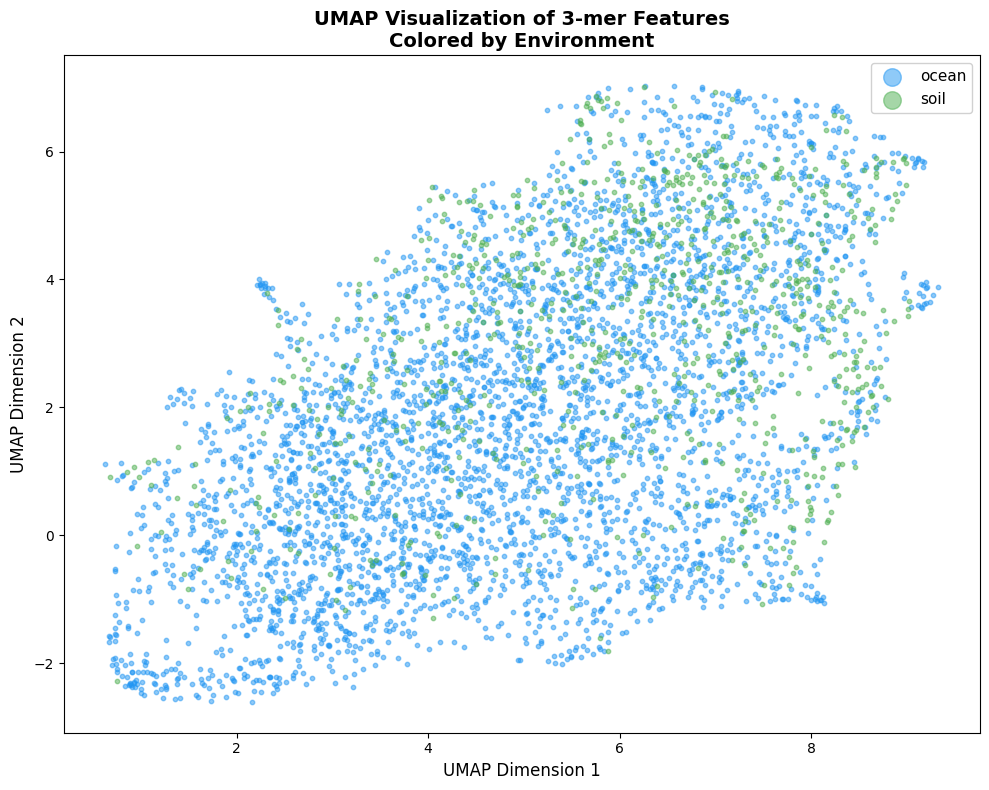

✅ UMAP plot saved


In [12]:
# ============================================================
# CELL 16: UMAP Visualization
# ============================================================

print("Running UMAP (this may take 2-5 minutes)...")

# Use top 20 PCs as input to UMAP
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    n_components=2,
    random_state=42,
    verbose=True
)

X_umap = reducer.fit_transform(X_pca[:, :20])
print(f"✅ UMAP complete. Shape: {X_umap.shape}")

fig, ax = plt.subplots(figsize=(10, 8))

for env in sorted(df['environment'].unique()):
    mask = y_vis == env
    ax.scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        c=env_color_map[env],
        label=env, alpha=0.5, s=10
    )

ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.set_title('UMAP Visualization of 3-mer Features\nColored by Environment',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=4,
          loc='best', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'umap_visualization.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ UMAP plot saved")

Running t-SNE (this may take 5-10 minutes)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4880 samples in 0.001s...
[t-SNE] Computed neighbors for 4880 samples in 2.705s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4880
[t-SNE] Computed conditional probabilities for sample 2000 / 4880
[t-SNE] Computed conditional probabilities for sample 3000 / 4880
[t-SNE] Computed conditional probabilities for sample 4000 / 4880
[t-SNE] Computed conditional probabilities for sample 4880 / 4880
[t-SNE] Mean sigma: 0.003762
[t-SNE] KL divergence after 250 iterations with early exaggeration: 83.377312
[t-SNE] KL divergence after 1000 iterations: 2.473123
✅ t-SNE complete. Shape: (4880, 2)


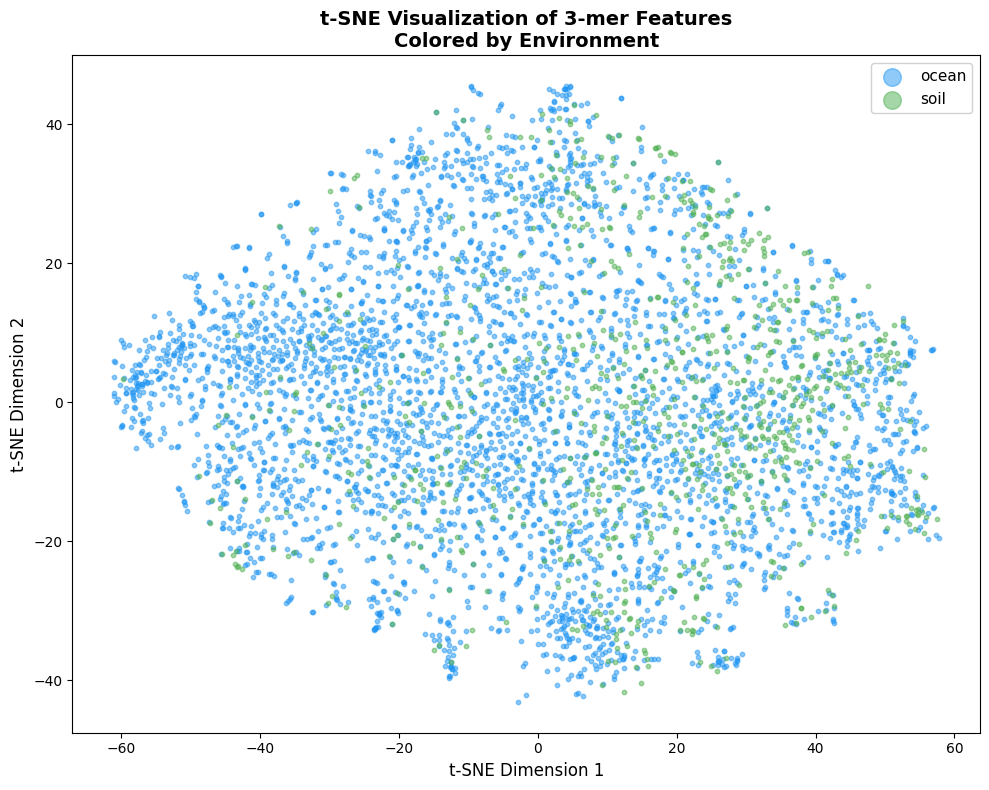

✅ t-SNE plot saved


In [13]:
# ============================================================
# CELL 17: t-SNE Visualization
# ============================================================

print("Running t-SNE (this may take 5-10 minutes)...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_iter=1000,
    verbose=1
)

# Use top 30 PCs as input
X_tsne = tsne.fit_transform(X_pca[:, :30])
print(f"✅ t-SNE complete. Shape: {X_tsne.shape}")

fig, ax = plt.subplots(figsize=(10, 8))

for env in sorted(df['environment'].unique()):
    mask = y_vis == env
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=env_color_map[env],
        label=env, alpha=0.5, s=10
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.set_title('t-SNE Visualization of 3-mer Features\nColored by Environment',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=4,
          loc='best', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_visualization.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE plot saved")

---
# SECTION 4: Classification Models

## Models Compared
1. **Random Forest** — ensemble tree-based model, with hyperparameter tuning
2. **Logistic Regression** — linear baseline on k-mer frequencies
3. **XGBoost** — gradient boosting, typically top performer
4. **Neural Network** — simple MLP (optional)

## Evaluation Metrics
- **Accuracy** — overall correct predictions
- **Precision** — correctness of positive predictions per class
- **Recall** — coverage of actual positives per class
- **F1-score** — harmonic mean of precision and recall
- **Confusion Matrix** — which environments are confused

In [15]:
# ============================================================
# CELL 19: Prepare Data for Classification
# ============================================================

# We will test all k values and all models
# Store all results here
all_results = []

# Label encoding
le = LabelEncoder()
y_all = le.fit_transform(df['environment'].values)

print(f"Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# Train/test split (80/20) — stratified
X_train_raw = {}
X_test_raw = {}
y_train_dict = {}
y_test_dict = {}

for k in [3, 4]:
    X = kmer_data[k].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_all,
        test_size=0.2,
        random_state=42,
        stratify=y_all
    )
    X_train_raw[k] = X_tr
    X_test_raw[k] = X_te
    y_train_dict[k] = y_tr
    y_test_dict[k] = y_te

    print(f"\nk={k} split:")
    print(f"  Train: {X_tr.shape}")
    print(f"  Test:  {X_te.shape}")

print("\n✅ Data splits ready for all k values")

Label encoding:
  0 = ocean
  1 = soil

k=3 split:
  Train: (3904, 8000)
  Test:  (976, 8000)

k=4 split:
  Train: (3904, 160000)
  Test:  (976, 160000)

✅ Data splits ready for all k values


In [ ]:
# ============================================================
# CELL 20: Train and Evaluate All Models
# ============================================================

def evaluate_model(model, X_test, y_test, model_name, k_val, label_names):
    """Evaluate a trained model and return results dictionary."""
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')

    print(f"\n  {'='*40}")
    print(f"  {model_name} (k={k_val})")
    print(f"  {'='*40}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1 Macro:  {f1:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=label_names))

    return {
        'model_name': model_name,
        'k': k_val,
        'accuracy': acc,
        'f1_macro': f1,
        'precision': prec,
        'recall': rec,
        'y_pred': y_pred,
        'model_obj': model
    }

# ---- Store trained models ----
trained_models = {}
label_names = le.classes_

# ============================================================
# Train for k=3 (best balance of features vs performance)
# ============================================================
k = 3
X_tr = X_train_raw[k]
X_te = X_test_raw[k]
y_tr = y_train_dict[k]
y_te = y_test_dict[k]

print("="*60)
print(f"TRAINING MODELS WITH k={k} FEATURES")
print("="*60)

# --- Model 1: Random Forest ---
print("\n[1/3] Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_tr, y_tr)
result_rf = evaluate_model(rf, X_te, y_te, "Random Forest", k, label_names)
all_results.append(result_rf)
trained_models['rf'] = rf

# --- Model 2: Logistic Regression ---
print("\n[2/3] Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=2000,
    C=1.0,
    solver='saga',
    multi_class='multinomial',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
lr.fit(X_tr, y_tr)
result_lr = evaluate_model(lr, X_te, y_te, "Logistic Regression", k, label_names)
all_results.append(result_lr)
trained_models['lr'] = lr

# --- Model 3: XGBoost ---
print("\n[3/3] Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_tr, y_tr)
result_xgb = evaluate_model(xgb, X_te, y_te, "XGBoost", k, label_names)
all_results.append(result_xgb)
trained_models['xgb'] = xgb

TRAINING MODELS WITH k=3 FEATURES

[1/3] Training Random Forest...

  Random Forest (k=3)
  Accuracy:  0.8166
  F1 Macro:  0.4901
  Precision: 0.6228
  Recall:    0.5159

              precision    recall  f1-score   support

       ocean       0.82      0.99      0.90       800
        soil       0.42      0.05      0.08       176

    accuracy                           0.82       976
   macro avg       0.62      0.52      0.49       976
weighted avg       0.75      0.82      0.75       976


[2/3] Training Logistic Regression...


In [ ]:
# ============================================================
# CELL 21: Confusion Matrix Heatmaps
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
y_te = y_test_dict[3]

model_results = [
    ("Random Forest", result_rf['y_pred']),
    ("Logistic Regression", result_lr['y_pred']),
    ("XGBoost", result_xgb['y_pred'])
]

for ax, (name, y_pred) in zip(axes, model_results):
    cm = confusion_matrix(y_te, y_pred)

    # Normalize confusion matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
        vmin=0, vmax=1
    )

    acc = accuracy_score(y_te, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrices — All Models (k=3 features)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved")

In [ ]:
# ============================================================
# CELL 22: Model Performance Comparison Bar Chart
# ============================================================

results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1 Macro': r['f1_macro'],
    'Precision': r['precision'],
    'Recall': r['recall']
} for r in all_results])

print("Model Performance Summary:")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

metrics = ['Accuracy', 'F1 Macro', 'Precision', 'Recall']
metric_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    bars = ax.bar(x + i*width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison\n(k=3 Features)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.6, color='red', linestyle='--',
           alpha=0.5, label='60% threshold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison plot saved")

In [ ]:
# ============================================================
# CELL 23: Feature Importance Analysis
# ============================================================

feature_names_k3 = get_all_kmers(3)

# Get feature importances from Random Forest
importances = trained_models['rf'].feature_importances_
indices = np.argsort(importances)[::-1][:50]

top_kmers_df = pd.DataFrame({
    'rank': range(1, 51),
    'kmer': [feature_names_k3[i] for i in indices],
    'importance': importances[indices]
})

# Annotate k-mers biologically
def annotate_kmer(kmer):
    hydrophobic = set('VILMFYW')
    charged_pos = set('KRH')
    charged_neg = set('DE')
    polar = set('NQST')

    notes = []
    aa_set = set(kmer)

    if aa_set.issubset(hydrophobic):
        notes.append('hydrophobic — membrane/structural')
    if aa_set.issubset(charged_pos):
        notes.append('positively charged — DNA binding')
    if aa_set.issubset(charged_neg):
        notes.append('negatively charged — metal repulsion')
    if 'P' in kmer:
        notes.append('proline — structural rigidity/heat stability')
    if 'C' in kmer:
        notes.append('cysteine — disulfide bonds/redox')
    if 'W' in kmer or 'H' in kmer:
        notes.append('aromatic/histidine — catalysis/metal binding')
    if aa_set.issubset(polar):
        notes.append('polar — solubility/surface exposed')
    if not notes:
        notes.append('mixed composition')

    return '; '.join(notes)

top_kmers_df['annotation'] = top_kmers_df['kmer'].apply(annotate_kmer)

# Save to CSV
kmers_path = os.path.join(OUTPUT_DIR, 'top50_important_kmers.csv')
top_kmers_df.to_csv(kmers_path, index=False)

print("Top 20 Most Important K-mers (Random Forest, k=3):")
print(top_kmers_df.head(20).to_string(index=False))
print(f"\n✅ Top 50 k-mers saved to: {kmers_path}")

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
top20 = top_kmers_df.head(20)

bars = ax.barh(
    range(20),
    top20['importance'][::-1].values,
    color='#2196F3',
    alpha=0.8
)
ax.set_yticks(range(20))
ax.set_yticklabels(top20['kmer'][::-1].values, fontsize=11, family='monospace')
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Top 20 Most Important 3-mers\n(Random Forest Classifier)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 0.00002,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.5f}',
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top20_important_kmers.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Top 20 k-mers plot saved")

In [ ]:
# ============================================================
# CELL 24: Environment Enrichment Analysis
# ============================================================

print("Computing k-mer enrichment per environment...")

kmer_df_k3 = kmer_data[3].copy()
kmer_df_k3['environment'] = df['environment'].values
overall_mean = kmer_data[3].mean()

enrichment_results = {}
top_enriched_per_env = {}

for env in sorted(df['environment'].unique()):
    env_mask = kmer_df_k3['environment'] == env
    env_mean = kmer_data[3][env_mask].mean()
    enrichment = env_mean / (overall_mean + 1e-10)
    enrichment_results[env] = enrichment

    top10 = enrichment.nlargest(10)
    top_enriched_per_env[env] = top10

    print(f"\n🔬 {env.upper()} — Top 10 enriched k-mers:")
    for kmer, ratio in top10.items():
        print(f"    {kmer}  →  {ratio:.2f}x enrichment  "
              f"[{annotate_kmer(kmer)}]")

# Visualization
fig, axes = plt.subplots(1, len(df['environment'].unique()),
                          figsize=(20, 6))

for ax, (env, color) in zip(axes, zip(sorted(df['environment'].unique()),
                                        colors)):
    top10 = top_enriched_per_env[env]
    ax.barh(range(len(top10)), top10.values[::-1],
            color=color, alpha=0.8)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10.index[::-1], fontsize=9, family='monospace')
    ax.set_xlabel('Enrichment Ratio', fontsize=9)
    ax.set_title(f'{env}\n(vs overall mean)', fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=1.0, color='black', linestyle='--', alpha=0.5)

plt.suptitle('K-mer Enrichment by Environment\n(Values > 1 = enriched)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'environment_enrichment.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Enrichment plot saved")

In [ ]:
# ============================================================
# CELL 25: Final Summary
# ============================================================

print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset:")
print(f"   Total sequences sampled: {len(df):,}")
print(f"   Environments: {list(df['environment'].unique())}")
print(f"   Sequences per environment: ~{TARGET_PER_ENV}")

print(f"\n🔬 Feature Engineering:")
for k, mat in kmer_data.items():
    print(f"   k={k}: {mat.shape[1]:,} features")

print(f"\n🤖 Model Performance (k=3):")
for r in all_results:
    print(f"   {r['model_name']:20s}: "
          f"Accuracy={r['accuracy']:.3f}, "
          f"F1={r['f1_macro']:.3f}")

best_result = max(all_results, key=lambda x: x['accuracy'])
print(f"\n🏆 Best Model: {best_result['model_name']} "
      f"(Accuracy = {best_result['accuracy']:.3f})")

print(f"\n📁 All output files saved to: {OUTPUT_DIR}/")

output_files = os.listdir(OUTPUT_DIR)
for f in sorted(output_files):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"   {f:45s} {size/1024:.1f} KB")

print("\n✅ PROJECT COMPLETE!")

In [ ]:
# ============================================================
# CELL 26: Package All Files for Submission
# ============================================================

import shutil
import zipfile

# Create zip of all outputs
zip_path = 'metagenomics_submission.zip'

with zipfile.ZipFile(zip_path, 'w') as zipf:
    for file in os.listdir(OUTPUT_DIR):
        file_path = os.path.join(OUTPUT_DIR, file)
        zipf.write(file_path, file)
        print(f"  Added: {file}")

print(f"\n✅ ZIP created: {zip_path}")
print(f"Size: {os.path.getsize(zip_path)/1024/1024:.2f} MB")
print("\nTo download: Right-click the zip file in VS Code Explorer → Reveal in File Explorer")